In [ ]:
import sys
from pathlib import Path

# Add src/ to Python path for local module imports
sys.path.insert(0, str(Path.cwd().parent / "src"))

In [230]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import json

import constants
from model_utils import *
from performance_utils import *

from ast import literal_eval
from pathlib import Path
 
import matplotlib.cm as cm
import ast
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
from pprint import pprint

from transformers import AutoTokenizer


In [231]:
model_type = constants.RectalCancerStagingData
base_dir = Path.cwd().parent

In [232]:
# Carichiamo i nostri file csv
file_names = {
    'train': constants.TRAIN_SPLIT_FILE_NAME,
    'validation': constants.VALIDATION_SPLIT_FILE_NAME,
    'test': constants.TEST_SPLIT_FILE_NAME,
}

paths = {split: Path('../data/' + file_name) for split, file_name in file_names.items()}

data = dict()
for split, path in paths.items():
    data[split] = pd.read_csv(path)

validation_data, test_data = data['validation'], data['test']
train_data = data['train']

################################
# Convert float columns to Int64
################################
float_cols = test_data.select_dtypes("float").columns
for col in float_cols:
    test_data[col] = test_data[col].round().astype("Int64")
    validation_data[col] = validation_data[col].round().astype("Int64")
    train_data[col] = train_data[col].round().astype("Int64")
    
# Check duplicatest
assert set(test_data.id) & set(validation_data.id) & set(train_data.id)== set(), "There are overlapping IDs between test and validation sets!"

print(f"{len(train_data) = }")
print(f"{len(test_data) = }")
print(f"{len(validation_data) = }")

len(train_data) = 187
len(test_data) = 65
len(validation_data) = 63


In [233]:
tokenizer_1 = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct", max_length=4096)
tokenizer_2 = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3", max_length=4096)

In [234]:
print(tokenizer_1('ciao'))
print(tokenizer_2('ciao'))

print(tokenizer_1.tokenize('ciao'))
print(tokenizer_2.tokenize('ciao'))

print(tokenizer_1.decode(tokenizer_1('ciao').input_ids))
print(tokenizer_2.decode(tokenizer_2('ciao').input_ids))

{'input_ids': [128000, 66, 23332], 'attention_mask': [1, 1, 1]}
{'input_ids': [1, 1045, 24753], 'attention_mask': [1, 1, 1]}
['c', 'iao']
['▁c', 'iao']
<|begin_of_text|>ciao
<s> ciao


In [235]:
def lunghezza_reports(reports: list[str]):
    rows = []
    for report in reports:
        tokens = tokenizer_1(report, truncation=False).input_ids
        characters = len(report)
        words = len(report.split())
        rows.append({
            'len_tokens': len(tokens),
            'len_characters': characters,
            'len_words': words
        })
    return pd.DataFrame.from_records(rows)

In [236]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,          # i caption in LaTeX sono spesso 9-10pt
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 150,       # per la preview; il salvataggio usa il suo
})

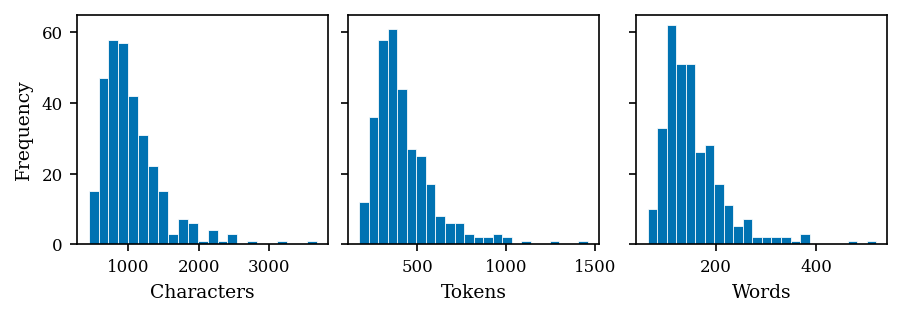

In [237]:
# Opzione 1: palette di seaborn pensata per daltonici
sns.set_palette("colorblind")

# Opzione 3: definire manualmente una palette sobria
colori = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#F0E442", "#56B4E9"]
sns.set_palette(colori)
df = lunghezza_reports(train_data.report_text.tolist() + validation_data.report_text.tolist() + test_data.report_text.tolist())

fig, axes = plt.subplots(1, 3, figsize=(5.9, 2), constrained_layout=True, sharey=True)
#fig.suptitle('Distribution of report lengths (characters, tokens, words)', fontsize='large')

sns.histplot(df['len_characters'], kde=False, ax=axes[0], edgecolor='white', alpha=1)
axes[0].set_xlabel('Characters')

sns.histplot(df['len_tokens'], kde=False, ax=axes[1], edgecolor='white', alpha=1)
axes[1].set_xlabel('Tokens')

sns.histplot(df['len_words'], kde=False, ax=axes[2], edgecolor='white', alpha=1)
axes[2].set_xlabel('Words')

axes[0].set_ylabel('Frequency')
for ax in axes[1:]:
    ax.set_ylabel('')

fig.savefig("distribuzione_lunghezze.pdf", bbox_inches="tight")
plt.show()

In [238]:
lunghezza_reports(train_data.report_text.tolist() + validation_data.report_text.tolist() + test_data.report_text.tolist()).describe().round()

,len_tokens,len_characters,len_words
count,315.0,315.0,315.0
mean,424.0,1049.0,154.0
std,173.0,436.0,62.0
min,176.0,435.0,64.0
25%,305.0,750.0,113.0
50%,381.0,939.0,140.0
75%,494.0,1234.0,180.0
max,1456.0,3672.0,519.0


In [239]:
total_data = pd.concat([train_data, validation_data, test_data], ignore_index=True)

In [240]:
total_data.shape

(315, 27)

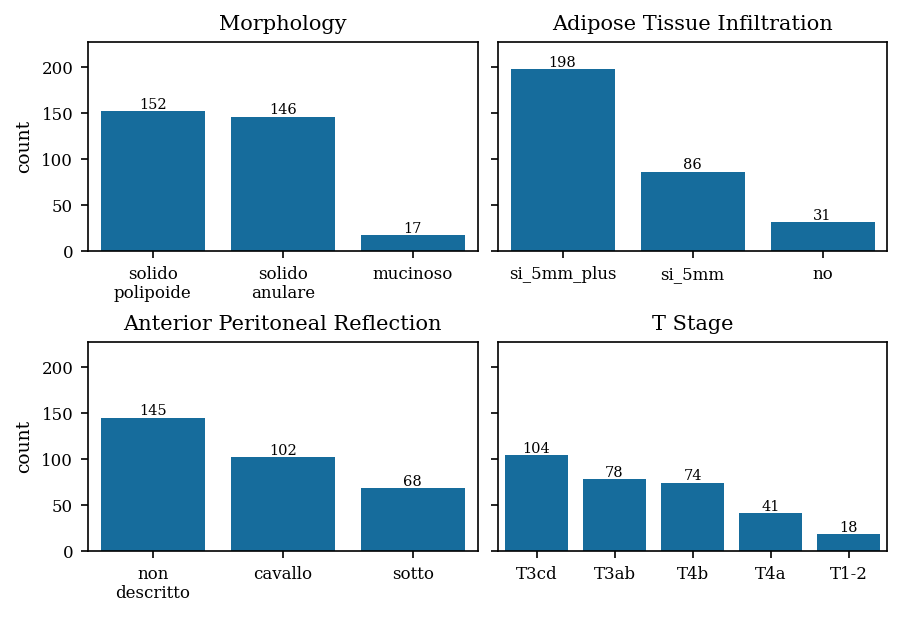

In [241]:
columns_plot = [
    'morfologia',
    'infiltrazione_tessuto_adiposo',
    #'coinvolgimento_fascia_mesorettale',
    'riflessione_peritoneale_anteriore',
    #'coinvolgimento_riflessione_peritoneale',
    'stadio_T',
    #'stadio_N',
    #'mrf',
    #'emvi',
    #'metastasi',
    #'infiltrazione_sfinteri',
    #'infiltrazione_organi_extra',
    #'linfonodi_sospetti',
    #'numero_linfonodi_non_conosciuto',
    #'lesioni_ossee',
    #'depositi_tumorali',
    #'numero_depositi',
]
titles = ['Morphology', 'Adipose Tissue Infiltration', 'Anterior Peritoneal Reflection', 'T Stage']

n_columns = 2
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(5.9, n_rows*2), constrained_layout=True, sharey=True)
axes = axes.flatten()

data_replaced = total_data.replace({
    'non_descritto': 'non\ndescritto',
    'solido_polipoide': 'solido\npolipoide',
    'solido_anulare': 'solido\nanulare'
    })

for i, col in enumerate(columns_plot):
    ax=axes[i]
    sns.countplot(data=data_replaced, x=col, order=data_replaced[col].value_counts().index, ax=ax)
    ax.set_title(titles[i])
    ax.set_xlabel(None)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom', fontsize=7)
    
    ax.margins(y=0.15)  # 15% di spazio extra in alto
    #ax.tick_params(axis='x', rotation=30)
    #plt.setp(ax.get_xticklabels(), ha='right')
# Rimuove eventuali assi vuoti
for j in range(len(columns_plot), len(axes)):
    fig.delaxes(axes[j])

fig.savefig("distribuzione_multiclass.pdf", bbox_inches="tight")
plt.show()

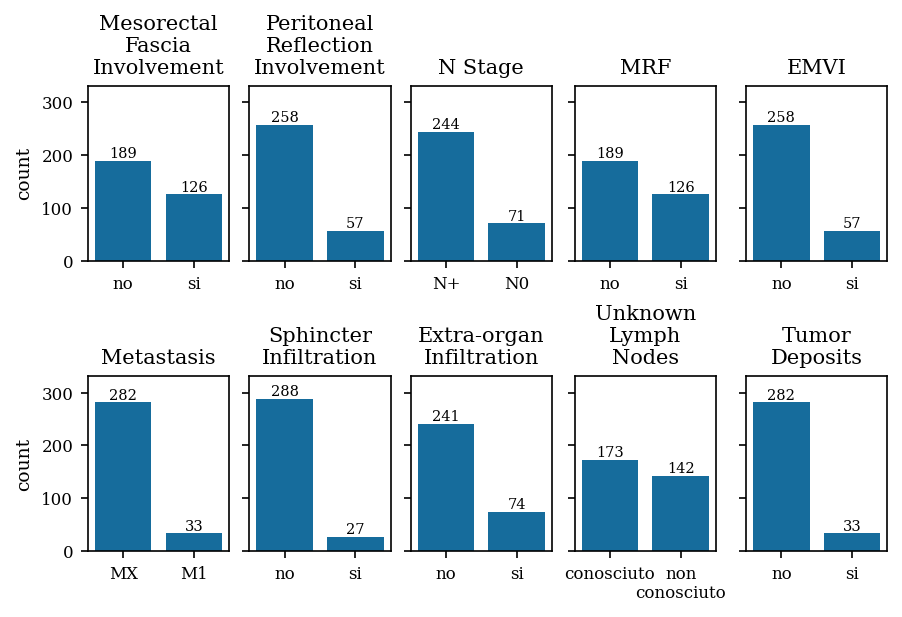

In [242]:
columns_plot = [
    'coinvolgimento_fascia_mesorettale',
    'coinvolgimento_riflessione_peritoneale',
    'stadio_N',
    'mrf',
    'emvi',
    'metastasi',
    'infiltrazione_sfinteri',
    'infiltrazione_organi_extra',
    'numero_linfonodi_non_conosciuto',
    'depositi_tumorali',
]
titles = ['Mesorectal\nFascia\nInvolvement', 'Peritoneal\nReflection\nInvolvement', 'N Stage', 'MRF', 'EMVI',
          'Metastasis', 'Sphincter\nInfiltration', 'Extra-organ\nInfiltration', 'Unknown\nLymph\nNodes', 'Tumor\nDeposits']

n_columns = 5
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(5.9, n_rows*2), constrained_layout=True, sharey=True)
axes = axes.flatten()

data_replaced = total_data.replace('non_conosciuto', 'non\nconosciuto')

for i, col in enumerate(columns_plot):
    ax=axes[i]
    sns.countplot(data=data_replaced, x=col, order=data_replaced[col].value_counts().index, ax=ax)
    ax.set_title(titles[i])
    ax.set_xlabel(None)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom', fontsize=7)
    
    ax.margins(y=0.15)  # 15% di spazio extra in alto
    #ax.tick_params(axis='x', rotation=30)
    #plt.setp(ax.get_xticklabels(), ha='right')
# Rimuove eventuali assi vuoti
for j in range(len(columns_plot), len(axes)):
    fig.delaxes(axes[j])

fig.savefig("distribuzione_binari.pdf", bbox_inches="tight")
#plt.tight_layout()
plt.show()

{'posizione': {'basso': 126, 'medio': 189, 'alto': 127, '\ngiunzione': 22}, 'sedi_linfonodi': {'mesorettali': 204, 'otturatori': 35, 'altro': 29, '\nrettali\nsuperiori': 119, '\niliaci': 34}, 'infiltrazione_organi_dettagli': {'altro': 46, 'pavimento\npelvico': 38, 'muscolo\nelevatore': 14}}


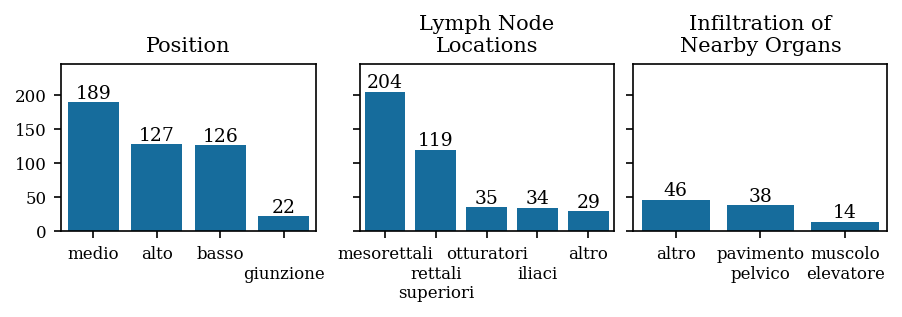

In [243]:
# Analisi posizione, sedi locoregionali, sedi non locoregionali
columns = ['posizione',
           'sedi_linfonodi',
           'infiltrazione_organi_dettagli']

titles = ['Position', 'Lymph Node\nLocations', 'Infiltration of\nNearby Organs']



possible_values = {
    col: [] for col in columns
    }

for col in columns:
    for s in total_data[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in total_data[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            continue
            
         
counts['posizione']['\ngiunzione'] = counts['posizione'].pop('giunzione')
counts['sedi_linfonodi']['\nrettali\nsuperiori'] = counts['sedi_linfonodi'].pop('rettali_superiori')
counts['sedi_linfonodi']['\niliaci'] = counts['sedi_linfonodi'].pop('iliaci')
counts['infiltrazione_organi_dettagli']['pavimento\npelvico'] = counts['infiltrazione_organi_dettagli'].pop('pavimento_pelvico')
counts['infiltrazione_organi_dettagli']['muscolo\nelevatore'] = counts['infiltrazione_organi_dettagli'].pop('muscolo_elevatore')
print(counts)
         
         
         
n_columns = 3
n_rows, r = divmod(len(columns), n_columns)
if r != 0:
    n_rows += 1
            
fig, axes = plt.subplots(n_rows, n_columns, figsize=(5.9, 2), constrained_layout=True, sharey=True)
axes = axes.flatten()
orientation = 'v'
for i, col in enumerate(columns):
    ax=axes[i]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient=orientation)
    # Add values on top of bars
    if orientation == 'v':
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    if orientation == 'h':
        for p in ax.patches:
            x_text = p.get_width()
            y_text = p.get_y() + p.get_height() / 2
            ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')
    ax.set_title(titles[i])
    ax.set_ylabel(None)
    ax.margins(y=0.20)  # 15% di spazio extra in alto
    #plt.setp(ax.get_xticklabels(), ha='right')
    
for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

fig.savefig("distribuzione_multilabel.pdf", bbox_inches="tight")
plt.show()

In [244]:
xxx = total_data.describe().loc[['count', 'min', 'mean', '50%', 'max']].drop(columns=['id']).round().T
xxx['Null values'] = 315 - xxx['count']
xxx.drop(columns=['count'], inplace=True)
display(xxx)

,min,mean,50%,max,Null values
ore_inizio,1.0,9.0,9.0,12.0,89.0
ore_fine,1.0,9.0,10.0,12.0,89.0
spessore_parietale,6.0,20.0,18.0,60.0,266.0
estensione_cranio_caudale,18.0,49.0,48.0,130.0,11.0
distanza_oai,0.0,43.0,45.0,110.0,23.0
linfonodi_sospetti,0.0,2.0,2.0,13.0,0.0


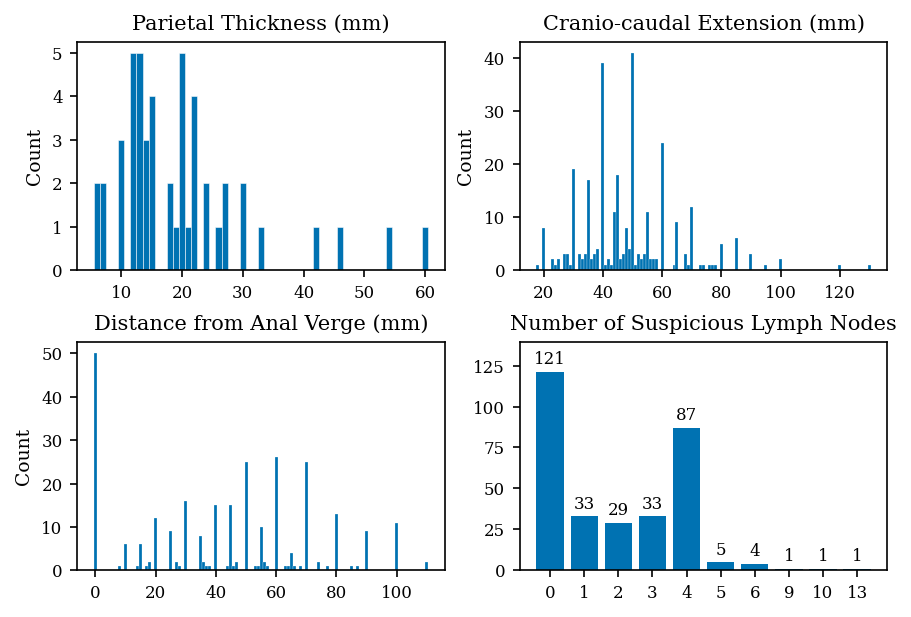

In [245]:
colonne_target_numeriche = [
    'spessore_parietale',
    'estensione_cranio_caudale',
    'distanza_oai',
    'linfonodi_sospetti',
    ]

titles = ['Parietal Thickness (mm)', 'Cranio-caudal Extension (mm)', 'Distance from Anal Verge (mm)', 'Number of Suspicious Lymph Nodes']

n_columns = 2
n_rows, r = divmod(len(colonne_target_numeriche), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(5.9, 4), constrained_layout=True)
axes=axes.flatten()

for i, col in enumerate(colonne_target_numeriche):
    ax = axes[i]
    if col == 'linfonodi_sospetti':
        counts = total_data[col].value_counts().sort_index()
        bars = ax.bar(counts.index.astype(str), counts.values)
        ax.bar_label(bars, padding=2, fontsize=8)
        ax.margins(y=0.15)  # 15% di spazio extra in alto
    else:
        sns.histplot(data=total_data, x=col, ax=ax, discrete=True, stat='count', kde=False, edgecolor='white', bins=15, alpha=1)
    ax.set_title(titles[i])
    ax.set_xlabel(None)
    
fig.savefig("distribuzione_numerici.pdf", bbox_inches="tight")
plt.show()

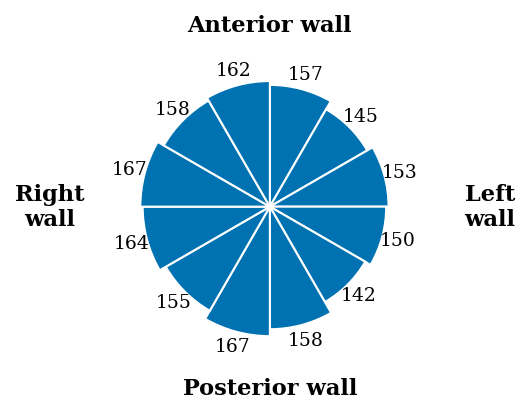

In [275]:
# Conta quante volte ogni ora è coperta da un arco tumorale
hour_counts = np.zeros(12)

for inizio, fine in zip(total_data.ore_inizio.dropna(), total_data.ore_fine.dropna()):
#for inizio, fine in zip([12, 12, 4, 10], [2, 6, 8, 1]):
    if inizio is None or fine is None:
        continue
    #if inizio ==12 and fine == 12:
    #    continue
    if inizio == fine:
        # Arco completo (circonferenziale)
        hour_counts += 1
    elif inizio < fine:
        for h in range(inizio, fine):
            hour_counts[h % 12] += 1
    else:
        # Wrap-around (es. da 10 a 2)
        for h in range(inizio, 12):
            hour_counts[h % 12] += 1
        for h in range(0, fine):
            hour_counts[h % 12] += 1
            

width = 2 * np.pi / 12

fig, ax = plt.subplots(figsize=(4, 3), subplot_kw={'projection': 'polar'})

# Orologio: 12 in alto, senso orario
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Angoli: ogni ora = 30 gradi
angles = np.linspace(0, 2 * np.pi, 12, endpoint=False) + (np.pi / 12)
width = 2 * np.pi / 12

bars = ax.bar(angles, hour_counts, width=width, edgecolor='white', linewidth=1)

clock_labels = ['']*12
ax.set_xticks(angles - (np.pi / 12))
ax.set_xticklabels(clock_labels, fontsize='x-small')

# Numeri sopra le barre
for angle, count in zip(angles, hour_counts):
    #ax.text(angle, count + max(hour_counts) * 0.05, f'{int(count)}',
    ax.text(angle, count + 20, f'{int(count)}',
            ha='center', va='center', fontsize='medium')

ax.set_yticklabels([])
r_label = max(hour_counts) * 1.4
ax.text(0, r_label, 'Anterior wall', ha='center', va='center', fontsize='large', fontweight='bold')
ax.text(np.pi, r_label, 'Posterior wall', ha='center', va='center', fontsize='large', fontweight='bold')
ax.text(np.pi / 2, r_label + 50, 'Left\nwall', ha='center', va='center', fontsize='large', fontweight='bold')
ax.text(3 * np.pi / 2, r_label + 50, 'Right\nwall', ha='center', va='center', fontsize='large', fontweight='bold')
ax.grid(False)
ax.spines['polar'].set_visible(False)
plt.tight_layout()
fig.savefig("distribuzione_ore.pdf", bbox_inches="tight")
plt.show()

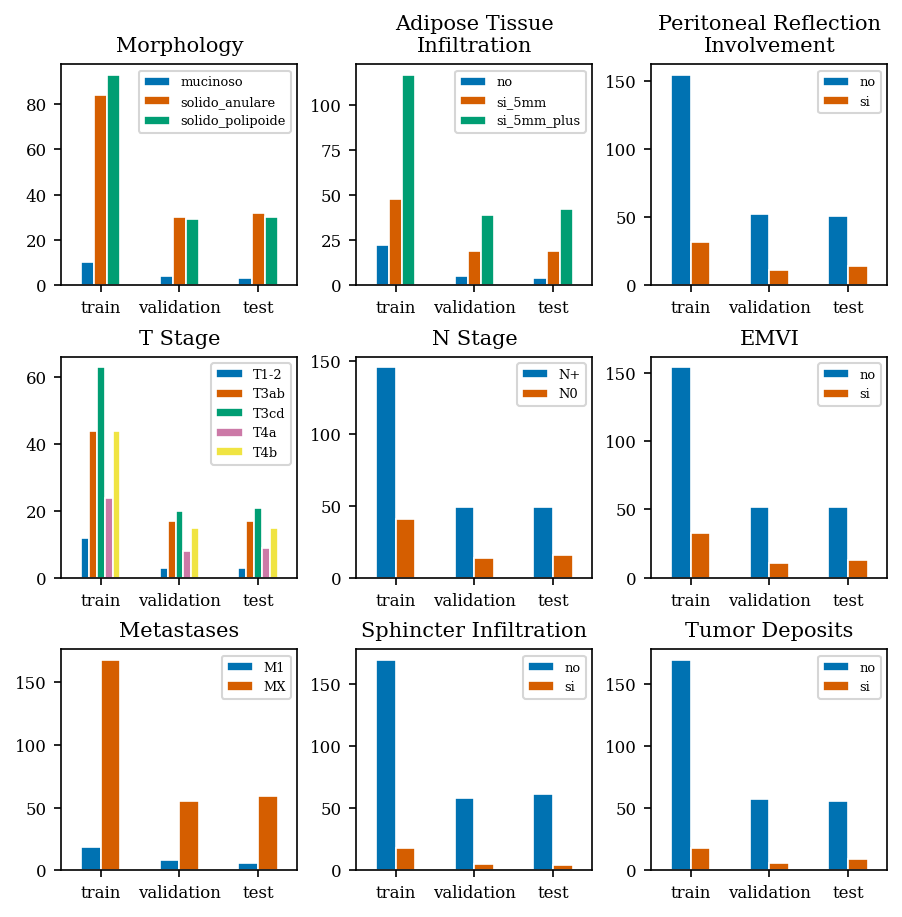

In [290]:
columns_plot = [
    'morfologia',
    'infiltrazione_tessuto_adiposo',
    'coinvolgimento_riflessione_peritoneale',
    'stadio_T',
    'stadio_N',
    'emvi',
    'metastasi',
    'infiltrazione_sfinteri',
    'depositi_tumorali',
]
titles = ['Morphology',
          'Adipose Tissue\nInfiltration',
          'Peritoneal Reflection\nInvolvement',
          'T Stage',
          'N Stage',
          'EMVI',
          'Metastases',
          'Sphincter Infiltration',
          'Tumor Deposits'
]

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1

fig, axes = plt.subplots(n_rows, n_columns, figsize=(5.9, n_rows * 2), constrained_layout=True, sharey=False)
axes = axes.flatten()

for i, col in enumerate(columns_plot):
    ax = axes[i]
    ct = total_data.groupby(['split', col]).size().unstack(fill_value=0)
    ct = ct.reindex(['train', 'validation', 'test'])
    ct.plot(kind='bar', ax=ax, edgecolor='white', linewidth=0.8)
    ax.set_title(titles[i])
    ax.set_xlabel(None)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize='x-small', title=None)

# Nascondi subplot vuoti
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    

fig.savefig("distribuzione_split.pdf", bbox_inches="tight")


#plt.suptitle('Categorical Field Distributions Across Splits', fontsize=14, fontweight='bold')
plt.show()

In [13]:
def report_model_to_dataframe(report_model: constants.RectalCancerStagingData, name: str) -> pd.DataFrame:
    multilabel_fields = ['posizione', 'infiltrazione_organi_dettagli', 'sedi_linfonodi']    
    model_dict = report_model.model_dump(mode='json')
    
    for f in multilabel_fields:
        label_list = []
        for l, v in model_dict[f].items():
            if v == constants.Flag.SI.value:
                label_list.append(l)
        model_dict[f] = label_list
    s = pd.Series(model_dict)
    s.name = name
    return s.to_frame()

In [14]:
def original_to_df(id: int, original_data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    result = original_data.loc[id, columns].T
    result.name = 'original'
    return result.to_frame()

In [15]:
def highlight_diff(row, color: str = 'red'):
    ref = row.iloc[1]  # prima colonna come riferimento
    styles = ['', '']  # nessuno stile per la colonna di riferimento
    for val in row.iloc[2:]:  # ultime tre colonne
        if val != ref:
            styles.append(f'background-color: {color}')
        else:
            styles.append('')
    return styles

In [16]:
print(reports.keys())

NameError: name 'reports' is not defined

In [ ]:
id = 87
original = original_to_df(id, data, list(constants.RectalCancerStagingData.model_fields.keys()))
dfs = [original] + [report_model_to_dataframe(r, n) for n, r in results[id].items()]
df = pd.concat(dfs, axis=1)
print(data.loc[id].interpretazioni)
styled = df.style.apply(highlight_diff, color='red', axis=1)

nan


In [ ]:
print(id, profiles[id])
pprint(reports[id])

87 GuidoImbemba
('SI EVIDENZIA ISPESSIMENTO PARIETALE AGGETTANTE NEL LUME DEL RETTO '
 'MEDIO-ALTO, A CIRCA 7 CM DA OAI, ESTESO PER CIRCA 5 CM, CHE INTERESSA CIRCA '
 'TRE-QUARTI DELLA CIRCONFERENZA DEL VISCERE CON EPICENTRO SUL VERSANTE '
 'ANTERO-LATERALE DI SINISTRA; LA LESIONE INFILTRA A TUTTO SPESSORE LA PARETE '
 'DEL RETTO, CON FINI SEGNI DI ESTENSIONE NEL CELLULARE ADIPOSO MESORETTALE. '
 'TRE LINFONODI, IL MAGGIORE DEI QUALI DEL DIAMETRO DI 6-7 MM, SI OSSERVANO IN '
 'SEDE EMORROIDARIA SUPERIORE, E ALTRI DI MINUTE DIMENSIONI IN SEDE '
 'MESORETTALE IL MAGGIORE DEI QUALI DI 5 MM SUL VERSANTE ANTERIORE SINISTRO '
 '(VEDI IMMAGINI PRINCIPALI). NON FALDE DI VERSAMENTO NELLO SCAVO PELVICO."')


In [ ]:
print(id)
display(styled)
print(id, profiles[id])
pprint(reports[id])

87


,original,actual,gpt,opus,mistral,gpt_tuned
morfologia,solido_anulare,solido_anulare,solido_polipoide,solido_polipoide,solido_polipoide,solido_polipoide
ore_inizio,nan,9,8,10,9,12
ore_fine,nan,6,4,6,6,9
spessore_parietale,nan,None,None,None,None,None
estensione_cranio_caudale,50.000000,50,50,50,50,50
distanza_oai,70.000000,70,70,70,70,70
posizione,"['medio', 'alto']","['medio', 'alto']","['medio', 'alto']","['medio', 'alto']","['medio', 'alto']","['medio', 'alto']"
riflessione_peritoneale_anteriore,nan,non_descritto,non_descritto,cavallo,non_descritto,non_descritto
infiltrazione_tessuto_adiposo,si_5mm,si_5mm,si_5mm,si_5mm,si_5mm,si_5mm
infiltrazione_sfinteri,nan,no,no,no,no,no


87 GuidoImbemba
('SI EVIDENZIA ISPESSIMENTO PARIETALE AGGETTANTE NEL LUME DEL RETTO '
 'MEDIO-ALTO, A CIRCA 7 CM DA OAI, ESTESO PER CIRCA 5 CM, CHE INTERESSA CIRCA '
 'TRE-QUARTI DELLA CIRCONFERENZA DEL VISCERE CON EPICENTRO SUL VERSANTE '
 'ANTERO-LATERALE DI SINISTRA; LA LESIONE INFILTRA A TUTTO SPESSORE LA PARETE '
 'DEL RETTO, CON FINI SEGNI DI ESTENSIONE NEL CELLULARE ADIPOSO MESORETTALE. '
 'TRE LINFONODI, IL MAGGIORE DEI QUALI DEL DIAMETRO DI 6-7 MM, SI OSSERVANO IN '
 'SEDE EMORROIDARIA SUPERIORE, E ALTRI DI MINUTE DIMENSIONI IN SEDE '
 'MESORETTALE IL MAGGIORE DEI QUALI DI 5 MM SUL VERSANTE ANTERIORE SINISTRO '
 '(VEDI IMMAGINI PRINCIPALI). NON FALDE DI VERSAMENTO NELLO SCAVO PELVICO."')


In [ ]:
print(reports[id])

SI EVIDENZIA ISPESSIMENTO PARIETALE AGGETTANTE NEL LUME DEL RETTO MEDIO-ALTO, A CIRCA 7 CM DA OAI, ESTESO PER CIRCA 5 CM, CHE INTERESSA CIRCA TRE-QUARTI DELLA CIRCONFERENZA DEL VISCERE CON EPICENTRO SUL VERSANTE ANTERO-LATERALE DI SINISTRA; LA LESIONE INFILTRA A TUTTO SPESSORE LA PARETE DEL RETTO, CON FINI SEGNI DI ESTENSIONE NEL CELLULARE ADIPOSO MESORETTALE. TRE LINFONODI, IL MAGGIORE DEI QUALI DEL DIAMETRO DI 6-7 MM, SI OSSERVANO IN SEDE EMORROIDARIA SUPERIORE, E ALTRI DI MINUTE DIMENSIONI IN SEDE MESORETTALE IL MAGGIORE DEI QUALI DI 5 MM SUL VERSANTE ANTERIORE SINISTRO (VEDI IMMAGINI PRINCIPALI). NON FALDE DI VERSAMENTO NELLO SCAVO PELVICO."
